In [3]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import pandas_market_calendars as mcal

In [5]:
START = "2016-01-01"
END   = "2026-02-20"
H     = 5

In [7]:
y = web.DataReader("NASDAQCOM", "fred", START, END).squeeze().dropna()
y.name = "nasdaq_close"

print(y.index.min().date(), y.index.max().date(), len(y))

2016-01-04 2026-02-20 2549


In [9]:
y = y.asfreq("B")
y = y.ffill()

print("Missing values:", y.isna().sum())

Missing values: 0


In [11]:
print("Weekend rows:", int((y.index.dayofweek >= 5).sum()))

Weekend rows: 0


In [13]:
y.to_csv("data/nasdaq_index.csv")

In [15]:
y = pd.read_csv("data/nasdaq_index.csv", index_col=0, parse_dates=True).squeeze()
y = y.asfreq("B")
y = y.ffill()

print(y.index.min().date(), y.index.max().date(), len(y))
y.head()

2016-01-04 2026-02-20 2645


DATE
2016-01-04    4903.09
2016-01-05    4891.43
2016-01-06    4835.76
2016-01-07    4689.43
2016-01-08    4643.63
Freq: B, Name: nasdaq_close, dtype: float64

In [17]:
r = np.log(y).diff().dropna()

print(r.head())
print("mean:", r.mean())
print("std:", r.std())

DATE
2016-01-05   -0.002381
2016-01-06   -0.011446
2016-01-07   -0.030727
2016-01-08   -0.009815
2016-01-11   -0.001215
Freq: B, Name: nasdaq_close, dtype: float64
mean: 0.0005827015166112653
std: 0.013606245329846637


In [19]:
from statsmodels.tsa.stattools import adfuller

adf = adfuller(r)

print("ADF statistic:", adf[0])
print("p-value:", adf[1])
print("lags:", adf[2])
print("observations:", adf[3])

ADF statistic: -13.478639134843997
p-value: 3.274248098089087e-25
lags: 15
observations: 2628


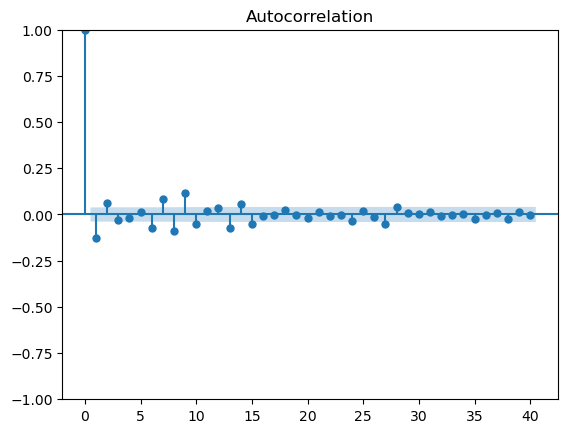

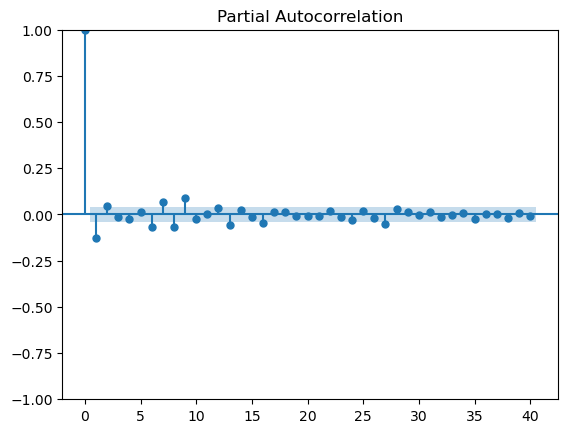

In [21]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(r, lags=40)
plt.show()

plot_pacf(r, lags=40, method="ywm")
plt.show()

In [23]:
split_date = "2025-01-01"

train_y = y.loc[:split_date]
test_y  = y.loc[split_date:]

train_r = r.loc[:split_date]
test_r  = r.loc[split_date:]

print(len(train_y), len(test_y))
print(train_y.index[-1], test_y.index[0])

2348 298
2025-01-01 00:00:00 2025-01-01 00:00:00
